In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.combine import SMOTEENN
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
model_df = pd.read_csv('telco_churn_ready_model.csv')

In [3]:
print(f"Data loaded successfully: {model_df.shape[0]} rows dan {model_df.shape[1]} columns.")
display(model_df.head())

Data loaded successfully: 7032 rows dan 20 columns.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 -- FEATURE ENGINEERING --

In [4]:
# Encoding Variable Dependen 
le = LabelEncoder()
model_df['Churn'] = le.fit_transform(model_df['Churn'])

In [5]:
# Encoding Independent Variables
# Separate binary (2 categories) and multinomial (> 2 categories) columns
binary_cols = [col for col in model_df.columns if model_df[col].dtype == 'O' and model_df[col].nunique() == 2]
multi_cols = [col for col in model_df.columns if model_df[col].dtype == 'O' and model_df[col].nunique() > 2]

# Label Encoding for binary columns
for col in binary_cols:
    model_df[col] = le.fit_transform(model_df[col])

# One-Hot Encoding for multinomial columns (Contract, PaymentMethod, etc)
model_df = pd.get_dummies(data=model_df, columns=multi_cols)

In [6]:
# Separation of Features and Targets
X = model_df.drop('Churn', axis=1)
y = model_df['Churn']

In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Feature Scaling
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [9]:
print(f"Number of Features: {X_train.shape[1]}")

Number of Features: 40


In [10]:
# Preparing Parameter List
param_grid_rf = {
    'n_estimators': [50, 100],      # Jumlah pohon
    'max_depth': [5, 10, None],      # Kedalaman pohon
    'min_samples_split': [2, 5]      # Minimal sampel untuk memecah cabang
}

In [11]:
# Initialization GridSearchCV 
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='recall', n_jobs=-1)

In [12]:
# Training by Finding the Best Combination
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [13]:
# Showing Best Results
print("Best Parameter:", grid_rf.best_params_)

Best Parameter: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [14]:
# Model Evaluation
y_pred = grid_rf.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



The accuracy value of the data produced is only 78%. This is due to data imbalance, so we have to balance the data to get a higher accuracy value.

-- HANDLING IMBALANCED DATA --

In [15]:
sm = SMOTEENN()
X_resampled, y_resampled = sm.fit_resample(X, y)

-- REAPET THE PHASES AFTER SMOTEENN --

In [16]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [17]:
param_grid1 = {
    'n_estimators': [100, 200],         
    'max_depth': [5, 10, None],         
    'min_samples_leaf': [2, 5, 10],     
    'criterion': ['gini', 'entropy']    
}

In [18]:
rf = RandomForestClassifier(random_state=42)
grid_search1 = GridSearchCV(estimator=rf, param_grid=param_grid1, cv=5, n_jobs=-1, scoring='recall', verbose=2)

In [19]:
grid_search1.fit(Xr_train, yr_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [20]:
print("Best Parameters After SMOOTEEN:", grid_search1.best_params_)
best_model_rf1 = grid_search1.best_estimator_

Best Parameters After SMOOTEEN: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}


In [21]:
yr_pred = best_model_rf1.predict(Xr_test)
print("\nClassification Report After SMOOTEEN:")
print(classification_report(yr_test, yr_pred))


Classification Report After SMOOTEEN:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       539
           1       0.95      0.97      0.96       629

    accuracy                           0.96      1168
   macro avg       0.96      0.96      0.96      1168
weighted avg       0.96      0.96      0.96      1168



In [22]:
print(confusion_matrix(yr_test, yr_pred))

[[507  32]
 [ 17 612]]


-- VISUALIZATION OF CHURN TRIGGERS --

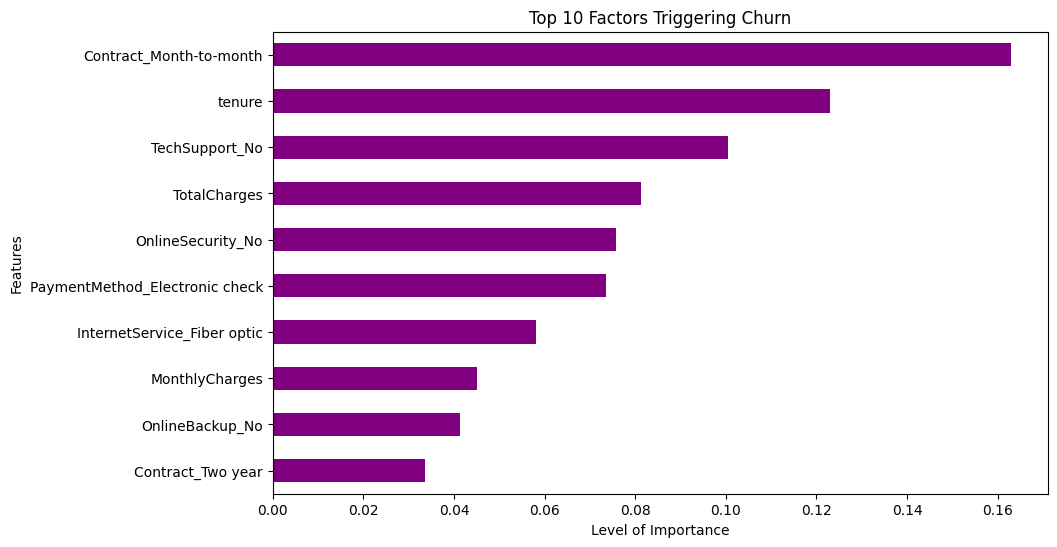

In [23]:
# Taking the best features from the GridSearchCV result model
best_rf = grid_rf.best_estimator_
importances = pd.Series(best_model_rf1.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10,6))
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Top 10 Factors Triggering Churn')
plt.xlabel('Level of Importance')
plt.ylabel('Features')
plt.show()

Conclusion: 
1. Data optimization with SMOTEENN can address data imbalance, improve model performance resulting in a 90%+ accuracy rate, and ensure the model has high sensitivity (recall) in detecting customers who are truly at risk of churning.
2. The feature that most influences a customer's decision to churn is the contract Month-to-month.
3. Customers using fiber optic internet services have a higher tendency to churn than DSL users.
4. Tenure feature (subscription length) is inversely proportional to churn risk.

-- SAVE DATA FOR APP --

In [24]:
# Saving Best Model
with open('model_churn_rf.pkl', 'wb') as f:
    pickle.dump(best_model_rf1, f)

# Save Scaler (sangat penting karena data baru nanti harus di-scale juga!)
with open('scaler_churn.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save Feature
feature_columns = X_train.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)